In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    f1_score, precision_score, recall_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

In [ ]:
patient_df = pd.read_csv('/content/drive/MyDrive/UoB_Interview_Task/dummy_data/cleaned_data.csv')

In [ ]:
xgb_los = pd.read_csv('/content/drive/MyDrive/UoB_Interview_Task/output/preds_xgb_los.csv')
xgb_mort = pd.read_csv('/content/drive/MyDrive/UoB_Interview_Task/output/preds_xgb_mort.csv')
lstm = pd.read_csv('/content/drive/MyDrive/UoB_Interview_Task/output/preds_lstm.csv')
transformer = pd.read_csv('/content/drive/MyDrive/UoB_Interview_Task/output/preds_transformer.csv')
llm = pd.read_csv('/content/drive/MyDrive/UoB_Interview_Task/output/llm.csv')
lstm_los = pd.read_csv('/content/drive/MyDrive/UoB_Interview_Task/output/preds_lstm_los.csv')
transformer_los = pd.read_csv('/content/drive/MyDrive/UoB_Interview_Task/output/preds_transformer_los.csv')

In [ ]:
lstm_los

,subject_id,y_true_los,y_pred_los
0,10007117,0.504167,0.629366
1,10007174,2.006250,6.258629
2,10011912,8.025695,8.758934
3,10018081,11.995139,3.326872
4,10030093,0.083333,0.614411
...,...,...,...
995,19974943,0.771528,3.739334
996,19984107,11.802083,8.222759
997,19984218,0.909722,3.922675
998,19986053,3.406250,2.401306


In [ ]:
lstm_mort = lstm[["subject_id","y_true_mort","y_prob_mort"]]
#lstm_los = lstm[["subject_id","y_true_los","y_pred_los"]]
transformer_mort = transformer[["subject_id","y_true_mort","y_prob_mort"]]
transformer_los = transformer[["subject_id","y_true_los","y_pred_los"]]

In [ ]:
xgb_los

,subject_id,y_true,y_prob
0,10007117,0.504167,1.067312
1,10007174,1.831944,10.290037
2,10007174,0.429861,0.323799
3,10007174,2.006250,4.534121
4,10011912,2.652778,2.629644
...,...,...,...
2246,19984218,6.138889,6.417913
2247,19984218,6.741667,11.776249
2248,19984218,0.909722,2.856390
2249,19986053,3.406250,2.944927


In [ ]:
lstm_los

,subject_id,y_true_los,y_pred_los
0,10007117,0.504167,0.629366
1,10007174,2.006250,6.258629
2,10011912,8.025695,8.758934
3,10018081,11.995139,3.326872
4,10030093,0.083333,0.614411
...,...,...,...
995,19974943,0.771528,3.739334
996,19984107,11.802083,8.222759
997,19984218,0.909722,3.922675
998,19986053,3.406250,2.401306


In [ ]:
xgb_los['task'] = 'regression'
xgb_mort['task'] = 'classification'
lstm_mort['task'] = 'classification'
lstm_los['task'] = 'regression'
transformer_mort['task'] = 'classification'
transformer_los['task'] = 'regression'
xgb_los['model'] = 'xgb'
xgb_mort['model'] = 'xgb'
lstm_mort['model'] = 'lstm'
lstm_los['model'] = 'lstm'
transformer_mort['model'] = 'transformer'
llm['model_name'] = "LLM - ClinicalBERT"

/tmp/ipython-input-3684329851.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lstm_mort['task'] = 'classification'
/tmp/ipython-input-3684329851.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transformer_mort['task'] = 'classification'
/tmp/ipython-input-3684329851.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [ ]:
xgb_los = xgb_los.rename(columns={"y_prob": "y_pred"})

In [ ]:
lstm_los = lstm_los.rename(columns={"y_true_los": "y_true", "y_pred_los": "y_pred"})
transformer_los = transformer_los.rename(columns={"y_true_los": "y_true", "y_pred_los": "y_pred"})
lstm_mort = lstm_mort.rename(columns={"y_true_mort": "y_true", "y_prob_mort": "y_prob"})
transformer_mort = transformer_mort.rename(columns={"y_true_mort": "y_true", "y_prob_mort": "y_prob"})

In [ ]:
llm

,Unnamed: 0,race,y_true,y_prob,y_pred,model_name
0,0,BLACK/CARIBBEAN ISLAND,0,0.001573,0,LLM - ClinicalBERT
1,1,WHITE,0,0.002323,0,LLM - ClinicalBERT
2,2,BLACK/AFRICAN AMERICAN,0,0.001151,0,LLM - ClinicalBERT
3,3,BLACK/AFRICAN AMERICAN,0,0.001810,0,LLM - ClinicalBERT
4,4,WHITE,0,0.025565,0,LLM - ClinicalBERT
...,...,...,...,...,...,...
2284,2284,WHITE,0,0.001207,0,LLM - ClinicalBERT
2285,2285,WHITE,0,0.362066,1,LLM - ClinicalBERT
2286,2286,WHITE,0,0.002116,0,LLM - ClinicalBERT
2287,2287,WHITE,0,0.009860,0,LLM - ClinicalBERT


In [ ]:
# Mortality (classification) — one row per admission (or patient if you already aggregated)
# Required cols somewhere: subject_id, y_true, y_prob; optional: hadm_id, split, model_name
classification_models = [
    ("LSTM_mort", lstm_mort),     # <- replace with your DF var
    ("XGB_mort", xgb_mort),     # <- replace
    ("Transformer_mort", transformer_mort),  # <- replace / remove if not applicable
]

# LOS (regression) — required: subject_id, y_true, y_pred
regression_models = [
    ("Transformer_LOS", transformer_los),  # <- replace
    ("XGB_LOS", xgb_los),         # <- replace
    ("LSTM_LOS", lstm_los)        # <- replace / remove if not applicable
]

# Demographics — must contain: subject_id, race
# If you already have this loaded, rename the variable here:
demo_df = patient_df[["subject_id", "race"]]  # <- replace with your demographics DF (subject_id, race)

In [ ]:
# ---- Config you can change ----
SPLIT_TO_USE = None   # set to None if you don't have a split column
AGGREGATE_TO_PATIENT = False  # set True if you want patient-level scoring

# For patient-level aggregation (if AGGREGATE_TO_PATIENT=True)
CLASS_PROB_AGG = "max"   # "max" or "mean"
REG_PRED_AGG  = "mean"   # "mean" (or implement "last" if you can identify last admission)


def _prep_class_df(name, df, demo_df):
    df = df.copy()
    df.columns = [c.lower() for c in df.columns]
    # common renames
    df = df.rename(columns={"prob": "y_prob", "prediction": "y_prob"})
    # filter split if present
    if SPLIT_TO_USE is not None and "split" in df.columns:
        df = df[df["split"].str.lower() == SPLIT_TO_USE.lower()].copy()
    df["model_name"] = name if "model_name" not in df.columns else df["model_name"]
    # essential columns
    needed = {"subject_id","y_true","y_prob"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"[{name}] missing columns: {missing}")
    # merge race
    d = df.merge(demo_df[["subject_id","race"]], on="subject_id", how="left")
    # patient-level aggregation if requested
    if AGGREGATE_TO_PATIENT:
        keep_first = lambda s: s.iloc[0]
        agg = {"y_true": "max", "race": keep_first}
        agg["y_prob"] = CLASS_PROB_AGG
        d = (d.groupby("subject_id", as_index=False)
               .agg(agg)
               .assign(model_name=name))
    return d[["model_name","subject_id","y_true","y_prob","race"]]

def _prep_reg_df(name, df, demo_df):
    df = df.copy()
    df.columns = [c.lower() for c in df.columns]
    # common renames
    df = df.rename(columns={"prediction": "y_pred"})
    if SPLIT_TO_USE is not None and "split" in df.columns:
        df = df[df["split"].str.lower() == SPLIT_TO_USE.lower()].copy()
    df["model_name"] = name if "model_name" not in df.columns else df["model_name"]
    needed = {"subject_id","y_true","y_pred"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"[{name}] missing columns: {missing}")
    d = df.merge(demo_df[["subject_id","race"]], on="subject_id", how="left")
    if AGGREGATE_TO_PATIENT:
        keep_first = lambda s: s.iloc[0]
        agg = {"y_true": "mean", "race": keep_first}
        agg["y_pred"] = REG_PRED_AGG
        d = (d.groupby("subject_id", as_index=False)
               .agg(agg)
               .assign(model_name=name))
    return d[["model_name","subject_id","y_true","y_pred","race"]]

# Build standardized frames
class_frames = [ _prep_class_df(name, df, demo_df) for name, df in classification_models ]
reg_frames   = [ _prep_reg_df(name, df, demo_df)   for name, df in regression_models ]

In [ ]:
class_frames.append(llm)

In [ ]:
class_frames

[     model_name  subject_id  y_true    y_prob             race
 0     LSTM_mort    10007117       0  0.004620            WHITE
 1     LSTM_mort    10007174       0  0.046033            WHITE
 2     LSTM_mort    10007174       0  0.046033            WHITE
 3     LSTM_mort    10007174       0  0.046033            WHITE
 4     LSTM_mort    10011912       0  0.067964  WHITE - RUSSIAN
 ...         ...         ...     ...       ...              ...
 2246  LSTM_mort    19984218       1  0.967546            WHITE
 2247  LSTM_mort    19984218       1  0.967546            WHITE
 2248  LSTM_mort    19984218       1  0.967546            WHITE
 2249  LSTM_mort    19986053       0  0.003960            WHITE
 2250  LSTM_mort    19986309       0  0.028817    BLACK/AFRICAN
 
 [2251 rows x 5 columns],
       model_name  subject_id  y_true        y_prob           race
 0       XGB_mort    10007117       0  4.410559e-06          WHITE
 1       XGB_mort    10007174       0  3.476410e-05          WHITE
 2 

class_frames

In [ ]:
def _best_f1_threshold(y_true, y_prob):
    from sklearn.metrics import precision_recall_curve
    prec, rec, th = precision_recall_curve(y_true, y_prob)
    if len(th) == 0:
        return 0.5
    f1s = 2 * (prec[1:] * rec[1:]) / np.clip(prec[1:] + rec[1:], 1e-12, None)
    return float(th[int(np.nanargmax(f1s))])

def _class_metrics(y_true, y_prob, thr):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)
    # AUC/AP need both classes:
    if np.unique(y_true).size > 1:
        auc = roc_auc_score(y_true, y_prob)
        ap  = average_precision_score(y_true, y_prob)
    else:
        auc = np.nan; ap = np.nan
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    spec = tn / max(tn+fp, 1)
    fpr  = 1 - spec
    prev = (y_true.sum() / len(y_true)) if len(y_true) else np.nan
    return {"ROC AUC": auc, "PR AUC": ap, "F1": f1, "Precision": prec, "Recall": rec,
            "Specificity": spec, "FPR": fpr, "TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "Prevalence": prev, "Threshold": thr}

def _reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-9, None))) * 100.0
    smape = np.mean(2.0*np.abs(y_pred - y_true) / np.clip(np.abs(y_pred)+np.abs(y_true), 1e-9, None)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2, "MAPE %": mape, "sMAPE %": smape}


In [ ]:
# ---- Mortality summaries ----
overall_cls_rows, byrace_cls_rows = [], []

for df in class_frames:
    model = df["model_name"].iloc[0]
    y_true = df["y_true"].to_numpy().astype(int)
    y_prob = df["y_prob"].to_numpy().astype(float)

    thr_star = _best_f1_threshold(y_true, y_prob)

    # overall
    overall_cls_rows.append({"Model": model} | _class_metrics(y_true, y_prob, thr_star))

    # by race evaluated at SAME threshold (per model)
    for r, g in df.groupby("race", dropna=False):
        rname = "Unknown" if pd.isna(r) else str(r)
        metrics = _class_metrics(g["y_true"], g["y_prob"], thr_star)
        byrace_cls_rows.append({"Model": model, "Race": rname, "N": len(g)} | metrics)

overall_cls = (pd.DataFrame(overall_cls_rows)
               .sort_values(["F1","ROC AUC","PR AUC"], ascending=[False,False,False]))
byrace_cls  = pd.DataFrame(byrace_cls_rows).sort_values(["Model","Race"])

# ---- LOS summaries ----
overall_reg_rows, byrace_reg_rows = [], []

for df in reg_frames:
    model = df["model_name"].iloc[0]
    y_true = df["y_true"].to_numpy().astype(float)
    y_pred = df["y_pred"].to_numpy().astype(float)

    overall_reg_rows.append({"Model": model} | _reg_metrics(y_true, y_pred))

    for r, g in df.groupby("race", dropna=False):
        rname = "Unknown" if pd.isna(r) else str(r)
        byrace_reg_rows.append(
            {"Model": model, "Race": rname, "N": len(g)} | _reg_metrics(g["y_true"], g["y_pred"])
        )

overall_reg = pd.DataFrame(overall_reg_rows).sort_values("MAE")
byrace_reg  = pd.DataFrame(byrace_reg_rows).sort_values(["Model","Race"])

print("=== Mortality (Overall) ==="); display(overall_cls)
print("\n=== Mortality (By Race) ==="); display(byrace_cls)
print("\n=== LOS (Overall) ==="); display(overall_reg)
print("\n=== LOS (By Race) ==="); display(byrace_reg)


=== Mortality (Overall) ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

,Model,ROC AUC,PR AUC,F1,Precision,Recall,Specificity,FPR,TP,FP,TN,FN,Prevalence,Threshold
1,XGB_mort,0.980423,0.572474,0.570093,0.502058,0.659459,0.989803,0.010197,122,121,11745,63,0.015351,0.293671
0,LSTM_mort,0.906324,0.382386,0.483932,0.372093,0.691892,0.895450,0.104550,128,216,1850,57,0.082186,0.622436
2,Transformer_mort,0.886010,0.359846,0.455446,0.359375,0.621622,0.900774,0.099226,115,205,1861,70,0.082186,0.867592
3,LLM - ClinicalBERT,0.898207,0.332984,0.415094,0.407407,0.423077,0.985695,0.014305,22,32,2205,30,0.022717,0.287268



=== Mortality (By Race) ===


,Model,Race,N,ROC AUC,PR AUC,F1,Precision,Recall,Specificity,FPR,TP,FP,TN,FN,Prevalence,Threshold
93,LLM - ClinicalBERT,AMERICAN INDIAN/ALASKA NATIVE,3,NaN,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,0,0,3,0,0.000000,0.287268
94,LLM - ClinicalBERT,ASIAN,30,NaN,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,0,0,30,0,0.000000,0.287268
95,LLM - ClinicalBERT,ASIAN - ASIAN INDIAN,3,NaN,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,0,0,3,0,0.000000,0.287268
96,LLM - ClinicalBERT,ASIAN - CHINESE,58,0.991228,0.500000,0.666667,0.500000,1.000000,0.982456,0.017544,1,1,56,0,0.017241,0.287268
97,LLM - ClinicalBERT,ASIAN - KOREAN,3,NaN,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,0,0,3,0,0.000000,0.287268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,XGB_mort,WHITE,8335,0.977458,0.609088,0.603175,0.505319,0.748031,0.988670,0.011330,95,93,8115,32,0.015237,0.293671
58,XGB_mort,WHITE - BRAZILIAN,12,NaN,NaN,0.000000,0.000000,0.000000,0.833333,0.166667,0,2,10,0,0.000000,0.293671
59,XGB_mort,WHITE - EASTERN EUROPEAN,18,1.000000,1.000000,0.666667,0.500000,1.000000,0.941176,0.058824,1,1,16,0,0.055556,0.293671
60,XGB_mort,WHITE - OTHER EUROPEAN,566,NaN,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,0,0,566,0,0.000000,0.293671



=== LOS (Overall) ===


,Model,MAE,RMSE,MSE,R2,MAPE %,sMAPE %
1,XGB_LOS,2.455324,5.401957,29.181142,0.394361,228.891344,60.900051
2,LSTM_LOS,2.906788,6.296195,39.642072,0.236750,130.776397,55.540885
0,Transformer_LOS,3.442542,6.794044,46.159036,0.111276,211.490891,68.553893



=== LOS (By Race) ===


,Model,Race,N,MAE,RMSE,MSE,R2,MAPE %,sMAPE %
62,LSTM_LOS,AMERICAN INDIAN/ALASKA NATIVE,5,9.230303,15.600461,243.374390,-0.129762,325.730174,74.038404
63,LSTM_LOS,ASIAN,34,2.753978,5.202291,27.063828,0.106482,80.944755,57.403279
64,LSTM_LOS,ASIAN - ASIAN INDIAN,4,0.503393,0.575299,0.330969,-7.480288,45.218869,50.954393
65,LSTM_LOS,ASIAN - CHINESE,39,3.116855,7.056836,49.798940,0.358923,120.559092,50.325506
66,LSTM_LOS,ASIAN - KOREAN,1,0.097141,0.097141,0.009436,NaN,5.105241,5.238972
...,...,...,...,...,...,...,...,...,...
57,XGB_LOS,WHITE,8335,2.241584,4.316316,18.630582,0.446316,289.634187,63.181155
58,XGB_LOS,WHITE - BRAZILIAN,12,3.014252,3.406424,11.603728,-0.011584,129.504550,77.864583
59,XGB_LOS,WHITE - EASTERN EUROPEAN,18,2.433120,3.690623,13.620702,-2.941802,583.733994,64.332654
60,XGB_LOS,WHITE - OTHER EUROPEAN,566,3.778172,7.723983,59.659907,0.185406,103.599701,54.516444


In [ ]:
# SAFE plotting helpers (local pyplot import avoids name collisions)

def plot_mortality_roc_overlay(class_frames, title="ROC — Mortality (all models)"):
    import numpy as np
    from sklearn.metrics import roc_curve, roc_auc_score
    import matplotlib.pyplot as plt  # local import ensures correct pyplot

    fig, ax = plt.subplots(figsize=(7, 6))
    any_ok = False

    for df in class_frames:
        model = df["model_name"].iloc[0]
        y_true = df["y_true"].to_numpy().astype(int)
        y_prob = df["y_prob"].to_numpy().astype(float)

        if np.unique(y_true).size < 2:
            print(f"[skip ROC] {model}: only one class present.")
            continue

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, label=f"{model} (AUC={auc:.3f})", linewidth=2)
        any_ok = True

    ax.plot([0, 1], [0, 1], "--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    if any_ok:
        ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_los_calibration_lines(reg_frames, n_bins=10, title="LOS — mean predicted vs mean true by decile"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt  # local import ensures correct pyplot

    # Build shared decile edges for fairness across models
    all_true = np.concatenate([df["y_true"].to_numpy().astype(float) for df in reg_frames if not df.empty])
    quantiles = np.linspace(0, 1, n_bins + 1)
    try:
        edges = np.unique(np.quantile(all_true, quantiles))
    except Exception:
        edges = np.linspace(all_true.min(), all_true.max(), n_bins + 1)

    fig, ax = plt.subplots(figsize=(7, 6))
    any_ok = False

    for df in reg_frames:
        model = df["model_name"].iloc[0]
        tmp = df[["y_true", "y_pred"]].copy()
        tmp["bin"] = pd.cut(tmp["y_true"], bins=edges, include_lowest=True, duplicates="drop")

        grp = (tmp.groupby("bin", observed=True)
                 .agg(mean_true=("y_true", "mean"),
                      mean_pred=("y_pred", "mean"),
                      n=("y_true", "size"))
                 .dropna()
                 .sort_values("mean_true"))

        if grp.empty:
            print(f"[skip LOS line] {model}: not enough bins.")
            continue

        ax.plot(grp["mean_true"].to_numpy(),
                grp["mean_pred"].to_numpy(),
                marker="o", linewidth=2, label=f"{model} (bins={len(grp)})")
        any_ok = True

    if len(all_true):
        lo, hi = float(np.min(all_true)), float(np.max(all_true))
        ax.plot([lo, hi], [lo, hi], "--", linewidth=1)  # ideal line

    ax.set_xlabel("True LOS (binned)")
    ax.set_ylabel("Predicted LOS (binned)")
    ax.set_title(title)
    if any_ok:
        ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.tight_layout()
    plt.show()


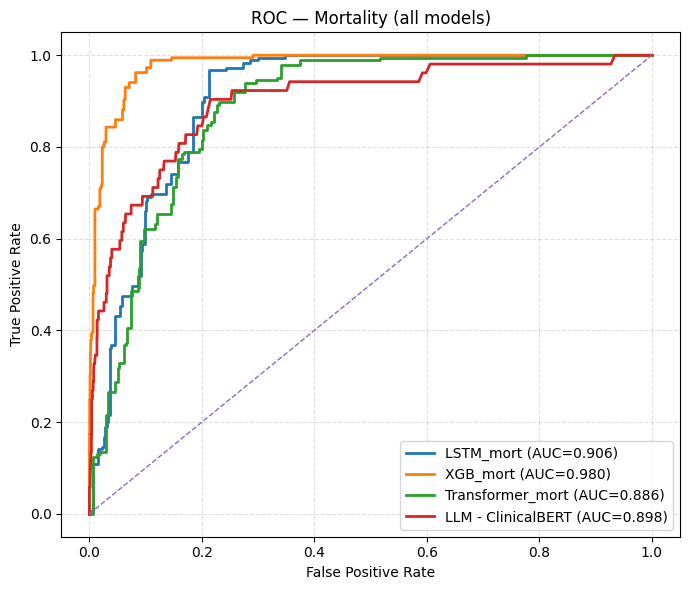

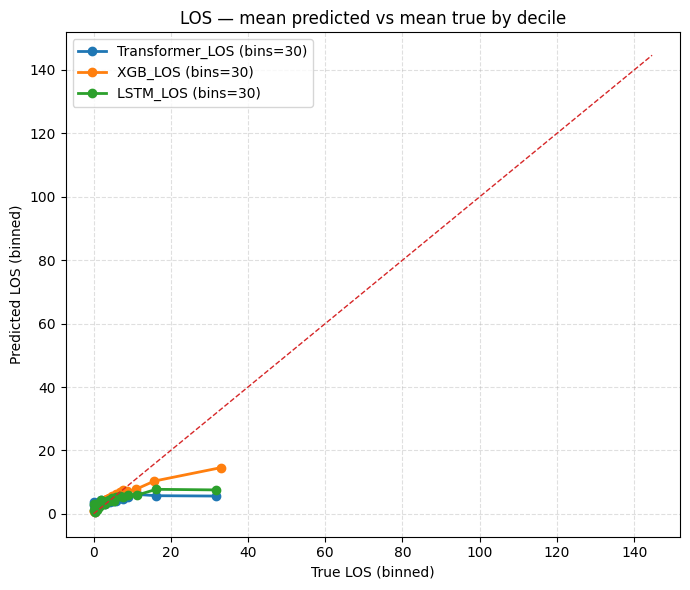

In [ ]:
plot_mortality_roc_overlay(class_frames)
plot_los_calibration_lines(reg_frames, n_bins=30)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score
)

def _best_f1_threshold(y_true, y_prob):
    """Pick threshold that maximizes F1."""
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    if len(thr) == 0:
        return 0.5
    f1s = 2 * (prec[1:] * rec[1:]) / np.clip(prec[1:] + rec[1:], 1e-12, None)
    return float(thr[int(np.nanargmax(f1s))])

def compute_metrics(y_true, y_prob, threshold):
    """Compute AUC, F1, precision, recall at given threshold."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    # AUC needs both classes
    if np.unique(y_true).size > 1:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan

    return {
      "AUC": round(auc, 2),
      "F1": round(f1_score(y_true, y_pred, zero_division=0), 2),
      "Precision": round(precision_score(y_true, y_pred, zero_division=0), 2),
      "Recall": round(recall_score(y_true, y_pred, zero_division=0), 2),
    }

In [ ]:
def summarize_models(class_frames):
    overall_rows = []
    byrace_rows = []
    macro_rows = []

    for df in class_frames:
        model = df["model_name"].iloc[0]
        y_true = df["y_true"]
        y_prob = df["y_prob"]

        # choose best F1 threshold on full dataset
        thr = _best_f1_threshold(y_true, y_prob)

        # overall metrics
        overall = compute_metrics(y_true, y_prob, thr)
        overall_rows.append({"Model": model, **overall})

        # by-race metrics
        race_metrics = []
        for race, g in df.groupby("race", dropna=False):
            race = "Unknown" if pd.isna(race) else str(race)
            m = compute_metrics(g["y_true"], g["y_prob"], thr)
            byrace_rows.append({"Model": model, "Race": race, "N": len(g), **m})
            race_metrics.append(m)

        # macro-average (mean across races)
        macro = {k: np.nanmean([r[k] for r in race_metrics]) for k in race_metrics[0]}
        macro_rows.append({"Model": model, **macro})

    overall_df = pd.DataFrame(overall_rows)
    byrace_df = pd.DataFrame(byrace_rows)
    macro_df  = pd.DataFrame(macro_rows)

    return overall_df, byrace_df, macro_df


In [ ]:
overall_cls, byrace_cls, macro_cls = summarize_models(class_frames)

print("=== Overall metrics (per model) ===")
display(overall_cls)

print("\n=== Metrics per race (per model) ===")
display(byrace_cls)

print("\n=== Macro-averaged across race (per model) ===")
display(macro_cls)


=== Overall metrics (per model) ===


,Model,AUC,F1,Precision,Recall
0,LSTM_mort,0.91,0.48,0.37,0.69
1,XGB_mort,0.98,0.57,0.50,0.66
2,Transformer_mort,0.89,0.46,0.36,0.62
3,LLM - ClinicalBERT,0.90,0.42,0.41,0.42



=== Metrics per race (per model) ===


,Model,Race,N,AUC,F1,Precision,Recall
0,LSTM_mort,AMERICAN INDIAN/ALASKA NATIVE,5,1.00,1.00,1.00,1.00
1,LSTM_mort,ASIAN,34,NaN,0.00,0.00,0.00
2,LSTM_mort,ASIAN - ASIAN INDIAN,4,NaN,0.00,0.00,0.00
3,LSTM_mort,ASIAN - CHINESE,39,1.00,1.00,1.00,1.00
4,LSTM_mort,ASIAN - KOREAN,1,NaN,0.00,0.00,0.00
...,...,...,...,...,...,...,...
118,LLM - ClinicalBERT,UNKNOWN,58,0.95,0.33,0.50,0.25
119,LLM - ClinicalBERT,WHITE,1431,0.89,0.43,0.43,0.42
120,LLM - ClinicalBERT,WHITE - EASTERN EUROPEAN,5,NaN,0.00,0.00,0.00
121,LLM - ClinicalBERT,WHITE - OTHER EUROPEAN,51,NaN,0.00,0.00,0.00



=== Macro-averaged across race (per model) ===


,Model,AUC,F1,Precision,Recall
0,LSTM_mort,0.922000,0.193871,0.178710,0.252258
1,XGB_mort,0.969000,0.168387,0.187742,0.180968
2,Transformer_mort,0.800000,0.105484,0.103226,0.113548
3,LLM - ClinicalBERT,0.840909,0.120000,0.108667,0.155667


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve

def _best_f1_threshold(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    if len(thr) == 0:
        return 0.5
    f1s = 2 * (prec[1:] * rec[1:]) / np.clip(prec[1:] + rec[1:], 1e-12, None)
    return float(thr[int(np.nanargmax(f1s))])

def compute_metrics(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_prob) if np.unique(y_true).size > 1 else np.nan
    return {
        "AUC": auc,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
    }


In [ ]:
def per_race_per_model(class_frames):
    rows = []
    for df in class_frames:
        model = df["model_name"].iloc[0]
        y_true = df["y_true"]
        y_prob = df["y_prob"]

        # threshold picked globally per model
        thr = _best_f1_threshold(y_true, y_prob)

        for race, g in df.groupby("race", dropna=False):
            race = "Unknown" if pd.isna(race) else str(race)
            m = compute_metrics(g["y_true"], g["y_prob"], thr)
            rows.append({"Model": model, "Race": race, **m, "N": len(g)})
    return pd.DataFrame(rows)


In [ ]:
perrace_df = per_race_per_model(class_frames)

# macro average across models (equal weight per model)
race_macro = (perrace_df
              .groupby("Race")[["AUC","F1","Precision","Recall"]]
              .mean()
              .round(2)
              .reset_index())

# optional: weighted average by number of samples in each subgroup
race_weighted = (perrace_df
                 .groupby("Race")
                 .apply(lambda g: pd.Series({
                     "AUC": round(np.average(g["AUC"], weights=g["N"]),2),
                     "F1": round(np.average(g["F1"], weights=g["N"]),2),
                     "Precision": round(np.average(g["Precision"], weights=g["N"]),2),
                     "Recall": round(np.average(g["Recall"], weights=g["N"]),2),
                 }))
                 .reset_index())


/tmp/ipython-input-1624315508.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [ ]:
print("=== Per race, averaged across models (macro) ===")
display(race_macro)

print("=== Per race, averaged across models (weighted by N) ===")
display(race_weighted)


=== Per race, averaged across models (macro) ===


,Race,AUC,F1,Precision,Recall
0,AMERICAN INDIAN/ALASKA NATIVE,0.83,0.50,0.50,0.50
1,ASIAN,NaN,0.00,0.00,0.00
2,ASIAN - ASIAN INDIAN,NaN,0.00,0.00,0.00
3,ASIAN - CHINESE,0.92,0.67,0.62,0.75
4,ASIAN - KOREAN,NaN,0.00,0.00,0.00
5,ASIAN - SOUTH EAST ASIAN,NaN,0.00,0.00,0.00
6,BLACK/AFRICAN,0.93,0.42,0.58,0.38
7,BLACK/AFRICAN AMERICAN,0.96,0.49,0.56,0.56
8,BLACK/CAPE VERDEAN,0.55,0.00,0.00,0.00
9,BLACK/CARIBBEAN ISLAND,NaN,0.00,0.00,0.00


=== Per race, averaged across models (weighted by N) ===


,Race,AUC,F1,Precision,Recall
0,AMERICAN INDIAN/ALASKA NATIVE,NaN,0.60,0.60,0.60
1,ASIAN,NaN,0.00,0.00,0.00
2,ASIAN - ASIAN INDIAN,NaN,0.00,0.00,0.00
3,ASIAN - CHINESE,0.95,0.77,0.74,0.85
4,ASIAN - KOREAN,NaN,0.00,0.00,0.00
5,ASIAN - SOUTH EAST ASIAN,NaN,0.00,0.00,0.00
6,BLACK/AFRICAN,0.95,0.44,0.82,0.34
7,BLACK/AFRICAN AMERICAN,0.97,0.54,0.78,0.49
8,BLACK/CAPE VERDEAN,NaN,0.00,0.00,0.00
9,BLACK/CARIBBEAN ISLAND,NaN,0.00,0.00,0.00


In [ ]:
def summarize_best_worst(race_df, metric_cols=["AUC","F1","Precision","Recall"]):
    summaries = []
    for metric in metric_cols:
        best_row = race_df.loc[race_df[metric].idxmax()]
        worst_row = race_df.loc[race_df[metric].idxmin()]
        summaries.append({
            "Metric": metric,
            "Best Model Performance (by Race)": best_row["Race"],
            "Best Value": round(best_row[metric], 3),
            "Worst Model Performance (by Race)": worst_row["Race"],
            "Worst Value": round(worst_row[metric], 3)
        })
    return pd.DataFrame(summaries)

# pick which table you want to analyze:
summary_macro = summarize_best_worst(race_macro)
summary_weighted = summarize_best_worst(race_weighted)

print("=== Best vs Worst (macro average across models) ===")
display(summary_macro)

print("=== Best vs Worst (weighted average across models) ===")
display(summary_weighted)


=== Best vs Worst (macro average across models) ===


,Metric,Best Model Performance (by Race),Best Value,Worst Model Performance (by Race),Worst Value
0,AUC,WHITE - EASTERN EUROPEAN,1.000,HISPANIC/LATINO - PUERTO RICAN,0.106
1,F1,ASIAN - CHINESE,0.667,ASIAN,0.000
2,Precision,ASIAN - CHINESE,0.625,ASIAN,0.000
3,Recall,ASIAN - CHINESE,0.750,ASIAN,0.000


=== Best vs Worst (weighted average across models) ===


,Metric,Best Model Performance (by Race),Best Value,Worst Model Performance (by Race),Worst Value
0,AUC,OTHER,0.975,UNABLE TO OBTAIN,0.785
1,F1,ASIAN - CHINESE,0.774,ASIAN,0.000
2,Precision,BLACK/AFRICAN,0.822,ASIAN,0.000
3,Recall,WHITE - EASTERN EUROPEAN,0.878,ASIAN,0.000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_auc_per_race(df, model_name="Transformer"):
    plt.figure(figsize=(7,6))
    any_ok = False

    for race, g in df.groupby("race", dropna=False):
        race_label = "Unknown" if pd.isna(race) else str(race)
        y_true = g["y_true"].to_numpy().astype(int)
        y_prob = g["y_prob"].to_numpy().astype(float)

        # skip if only one class present
        if np.unique(y_true).size < 2:
            print(f"[skip ROC] {race_label}: only one class present")
            continue

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{race_label} (AUC={auc:.3f}, N={len(g)})", linewidth=2)
        any_ok = True

    # chance line
    plt.plot([0,1],[0,1], "--", color="gray", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC by Race — {model_name}")
    if any_ok:
        plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [ ]:
df_transformer = transformer_mort.merge(
    patient_df[["subject_id", "race"]],
    on="subject_id",
    how="left"
)

In [ ]:
df_lstm = lstm_mort.merge(
    patient_df[["subject_id", "race"]],
    on="subject_id",
    how="left"
)

[skip ROC] ASIAN: only one class present
[skip ROC] ASIAN - ASIAN INDIAN: only one class present
[skip ROC] ASIAN - KOREAN: only one class present
[skip ROC] ASIAN - SOUTH EAST ASIAN: only one class present
[skip ROC] BLACK/CAPE VERDEAN: only one class present
[skip ROC] BLACK/CARIBBEAN ISLAND: only one class present
[skip ROC] HISPANIC/LATINO - CENTRAL AMERICAN: only one class present
[skip ROC] HISPANIC/LATINO - DOMINICAN: only one class present
[skip ROC] HISPANIC/LATINO - GUATEMALAN: only one class present
[skip ROC] HISPANIC/LATINO - HONDURAN: only one class present
[skip ROC] HISPANIC/LATINO - MEXICAN: only one class present
[skip ROC] HISPANIC/LATINO - PUERTO RICAN: only one class present
[skip ROC] HISPANIC/LATINO - SALVADORAN: only one class present
[skip ROC] MULTIPLE RACE/ETHNICITY: only one class present
[skip ROC] NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER: only one class present
[skip ROC] PATIENT DECLINED TO ANSWER: only one class present
[skip ROC] PORTUGUESE: only one c

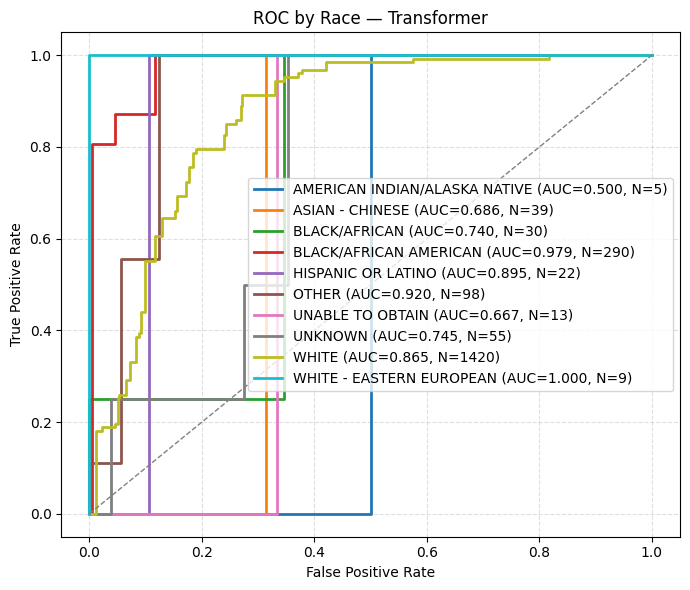

In [ ]:
# assuming your transformer mortality dataframe is called df_tx_mort
plot_auc_per_race(df_transformer, model_name="Transformer")


[skip ROC] ASIAN: only one class present
[skip ROC] ASIAN - ASIAN INDIAN: only one class present
[skip ROC] ASIAN - KOREAN: only one class present
[skip ROC] ASIAN - SOUTH EAST ASIAN: only one class present
[skip ROC] BLACK/CAPE VERDEAN: only one class present
[skip ROC] BLACK/CARIBBEAN ISLAND: only one class present
[skip ROC] HISPANIC/LATINO - CENTRAL AMERICAN: only one class present
[skip ROC] HISPANIC/LATINO - DOMINICAN: only one class present
[skip ROC] HISPANIC/LATINO - GUATEMALAN: only one class present
[skip ROC] HISPANIC/LATINO - HONDURAN: only one class present
[skip ROC] HISPANIC/LATINO - MEXICAN: only one class present
[skip ROC] HISPANIC/LATINO - PUERTO RICAN: only one class present
[skip ROC] HISPANIC/LATINO - SALVADORAN: only one class present
[skip ROC] MULTIPLE RACE/ETHNICITY: only one class present
[skip ROC] NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER: only one class present
[skip ROC] PATIENT DECLINED TO ANSWER: only one class present
[skip ROC] PORTUGUESE: only one c

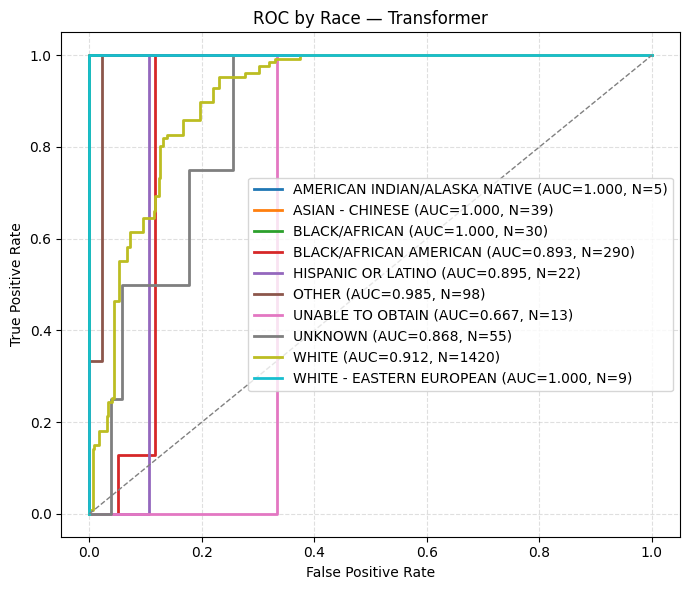

In [ ]:
plot_auc_per_race(df_lstm, model_name="Transformer")

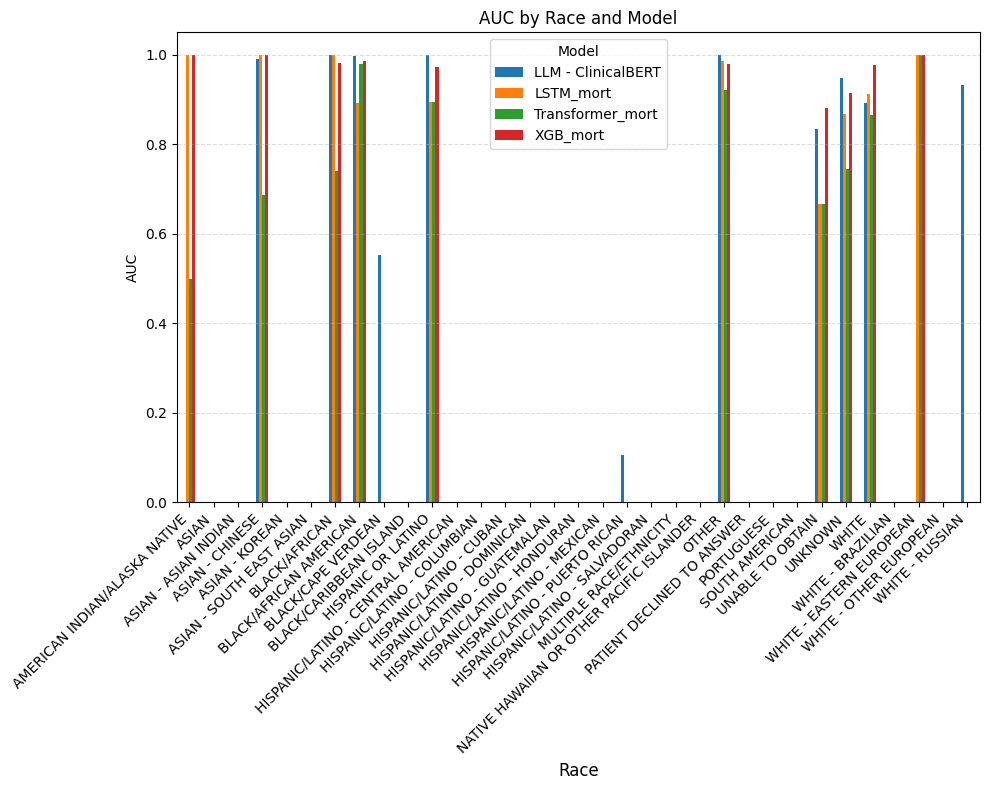

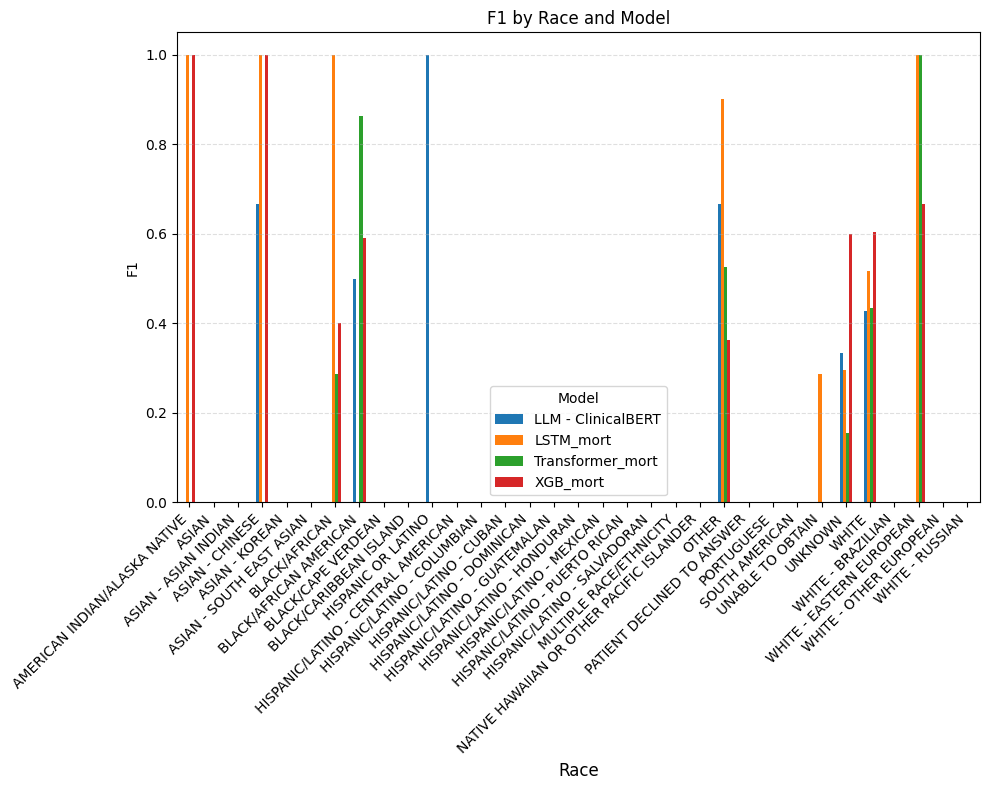

In [ ]:
import matplotlib.pyplot as plt

def plot_bar_by_race(perrace_df, metric="AUC"):
    # perrace_df = table with Model, Race, AUC, F1, Precision, Recall
    pivot = perrace_df.pivot(index="Race", columns="Model", values=metric)
    pivot.plot(kind="bar", figsize=(10,8))
    plt.title(f"{metric} by Race and Model")
    plt.ylabel(metric)
    plt.xlabel("Race", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

# example
plot_bar_by_race(perrace_df, metric="AUC")
plot_bar_by_race(perrace_df, metric="F1")

In [ ]:
def plot_gap(summary_df):
    # summary_df = output from summarize_best_worst earlier
    plt.figure(figsize=(6,4))
    plt.bar(summary_df["Metric"], summary_df["Best Value"] - summary_df["Worst Value"])
    plt.title("Performance Gap (Best–Worst Race)")
    plt.ylabel("Gap")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

def plot_pr_per_race(df, model_name="Transformer"):
    plt.figure(figsize=(7,6))
    any_ok = False

    for race, g in df.groupby("race", dropna=False):
        race_label = "Unknown" if pd.isna(race) else str(race)
        y_true = g["y_true"].to_numpy().astype(int)
        y_prob = g["y_prob"].to_numpy().astype(float)

        # skip if only one class present
        if np.unique(y_true).size < 2:
            print(f"[skip PR] {race_label}: only one class present")
            continue

        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        plt.plot(rec, prec, label=f"{race_label} (AP={ap:.3f}, N={len(g)})", linewidth=2)
        any_ok = True

    # baseline: prevalence of positive class
    base = df["y_true"].mean()
    plt.hlines(base, 0, 1, linestyle="--", color="gray", linewidth=1)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall by Race — {model_name}")
    if any_ok:
        plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


[skip PR] ASIAN: only one class present
[skip PR] ASIAN - ASIAN INDIAN: only one class present
[skip PR] ASIAN - KOREAN: only one class present
[skip PR] ASIAN - SOUTH EAST ASIAN: only one class present
[skip PR] BLACK/CAPE VERDEAN: only one class present
[skip PR] BLACK/CARIBBEAN ISLAND: only one class present
[skip PR] HISPANIC/LATINO - CENTRAL AMERICAN: only one class present
[skip PR] HISPANIC/LATINO - DOMINICAN: only one class present
[skip PR] HISPANIC/LATINO - GUATEMALAN: only one class present
[skip PR] HISPANIC/LATINO - HONDURAN: only one class present
[skip PR] HISPANIC/LATINO - MEXICAN: only one class present
[skip PR] HISPANIC/LATINO - PUERTO RICAN: only one class present
[skip PR] HISPANIC/LATINO - SALVADORAN: only one class present
[skip PR] MULTIPLE RACE/ETHNICITY: only one class present
[skip PR] NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER: only one class present
[skip PR] PATIENT DECLINED TO ANSWER: only one class present
[skip PR] PORTUGUESE: only one class present
[ski

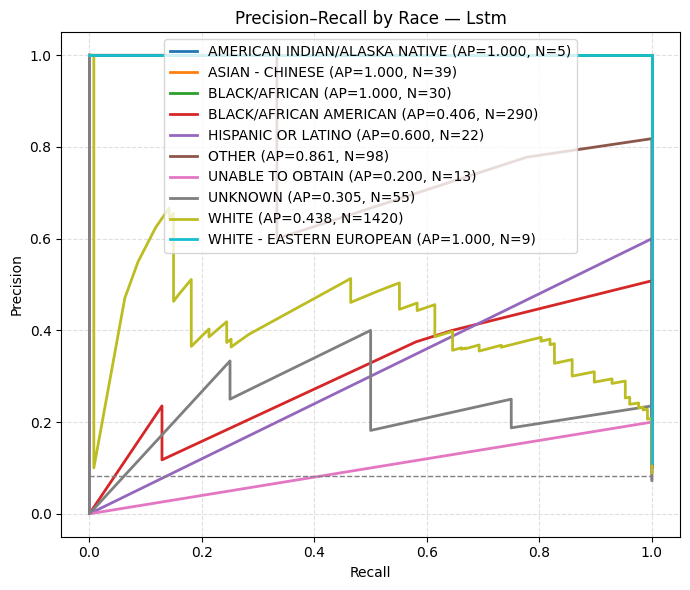

In [ ]:
plot_pr_per_race(df_lstm, model_name="Lstm")


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-9, None))) * 100
    smape = np.mean(2 * np.abs(y_pred - y_true) / np.clip(np.abs(y_pred) + np.abs(y_true), 1e-9, None)) * 100
    return {"MAE": mae, "RMSE": rmse, "R²": r2, "MAPE %": mape, "sMAPE %": smape}

def compare_los_by_race(df):
    rows = []
    for race, g in df.groupby("race", dropna=False):
        rname = "Unknown" if pd.isna(race) else str(race)
        metrics = regression_metrics(g["y_true"].to_numpy(), g["y_pred"].to_numpy())
        rows.append({"Race": rname, "N": len(g), **metrics})
    return pd.DataFrame(rows).sort_values("MAE")

# Example usage
transformer_los = transformer_los.merge(patient_df[["subject_id","race"]], on="subject_id", how="left")
summary_by_race = compare_los_by_race(transformer_los)
print(summary_by_race)


                                         Race     N        MAE       RMSE  \
4                              ASIAN - KOREAN     1   0.096052   0.096052   
11         HISPANIC/LATINO - CENTRAL AMERICAN     2   0.640732   0.870925   
9                      BLACK/CARIBBEAN ISLAND    15   0.812849   1.023518   
13               HISPANIC/LATINO - GUATEMALAN     3   1.416565   1.670706   
5                    ASIAN - SOUTH EAST ASIAN     2   1.533654   2.053357   
12                HISPANIC/LATINO - DOMINICAN    31   1.547393   2.065716   
2                        ASIAN - ASIAN INDIAN     4   1.890480   2.539823   
27                          WHITE - BRAZILIAN     8   1.939843   2.339991   
14                 HISPANIC/LATINO - HONDURAN     1   2.013785   2.013785   
19  NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER     2   2.020605   2.223730   
10                         HISPANIC OR LATINO    22   2.147283   3.585624   
17               HISPANIC/LATINO - SALVADORAN     5   2.149851   2.921540   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [ ]:
def plot_residuals_by_race(df, model_name="LOS Model"):
    """Boxplot of residuals (y_pred - y_true) across race groups."""
    df = df.copy()
    df["residual"] = df["y_pred"] - df["y_true"]

    plt.figure(figsize=(14,10))
    sns.boxplot(data=df, x="race", y="residual", palette="Set2")
    plt.axhline(0, linestyle="--", color="gray")
    plt.title(f"Residuals by Race — {model_name}")
    plt.ylabel("Residual (Predicted – True LOS)")
    plt.xlabel("Race", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

def plot_mae_by_race(df, model_name="LOS Model"):
    """Bar chart of MAE across race groups."""
    maes = []
    for race, g in df.groupby("race", dropna=False):
        rname = "Unknown" if pd.isna(race) else str(race)
        mae = mean_absolute_error(g["y_true"], g["y_pred"])
        maes.append({"Race": rname, "MAE": mae, "N": len(g)})

    mae_df = pd.DataFrame(maes).sort_values("MAE")

    plt.figure(figsize=(14,10))
    sns.barplot(data=mae_df, x="Race", y="MAE", palette="viridis")
    plt.title(f"MAE by Race — {model_name}")
    plt.ylabel("Mean Absolute Error (days)")
    plt.xlabel("Race", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    for i, row in mae_df.iterrows():
        plt.text(i, row["MAE"]+0.2, f"N={row['N']}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    return mae_df


/tmp/ipython-input-3546593335.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mae_df, x="Race", y="MAE", palette="viridis")


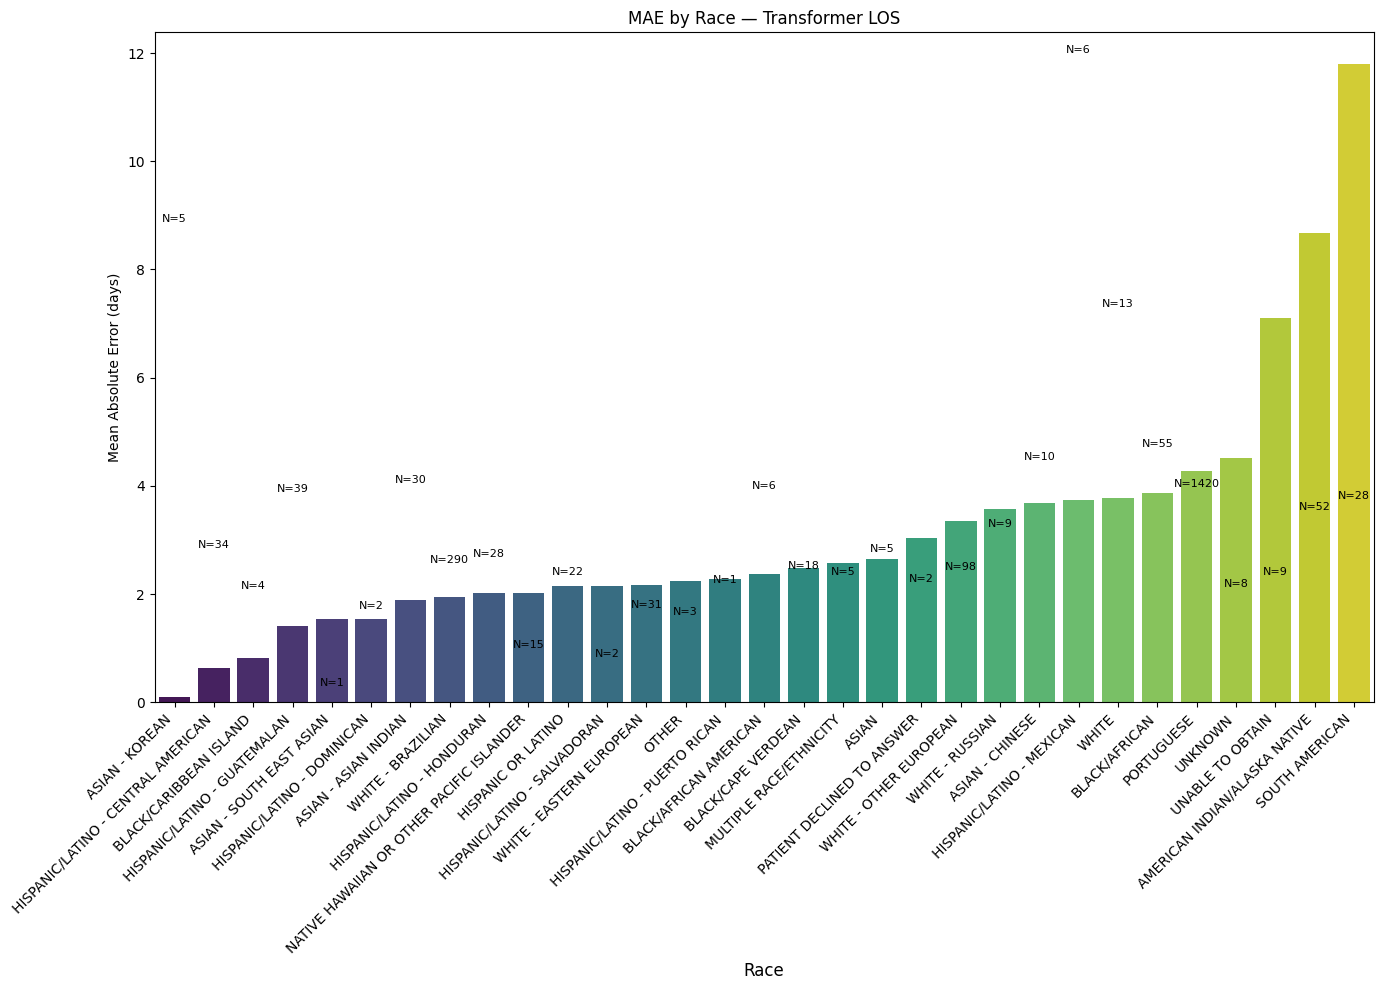

,Race,MAE,N
4,ASIAN - KOREAN,0.096052,1
11,HISPANIC/LATINO - CENTRAL AMERICAN,0.640732,2
9,BLACK/CARIBBEAN ISLAND,0.812849,15
13,HISPANIC/LATINO - GUATEMALAN,1.416565,3
5,ASIAN - SOUTH EAST ASIAN,1.533654,2
12,HISPANIC/LATINO - DOMINICAN,1.547393,31
2,ASIAN - ASIAN INDIAN,1.890480,4
27,WHITE - BRAZILIAN,1.939843,8
14,HISPANIC/LATINO - HONDURAN,2.013785,1
19,NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,2.020605,2


/tmp/ipython-input-3566178146.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="race", y="residual", palette="Set2")


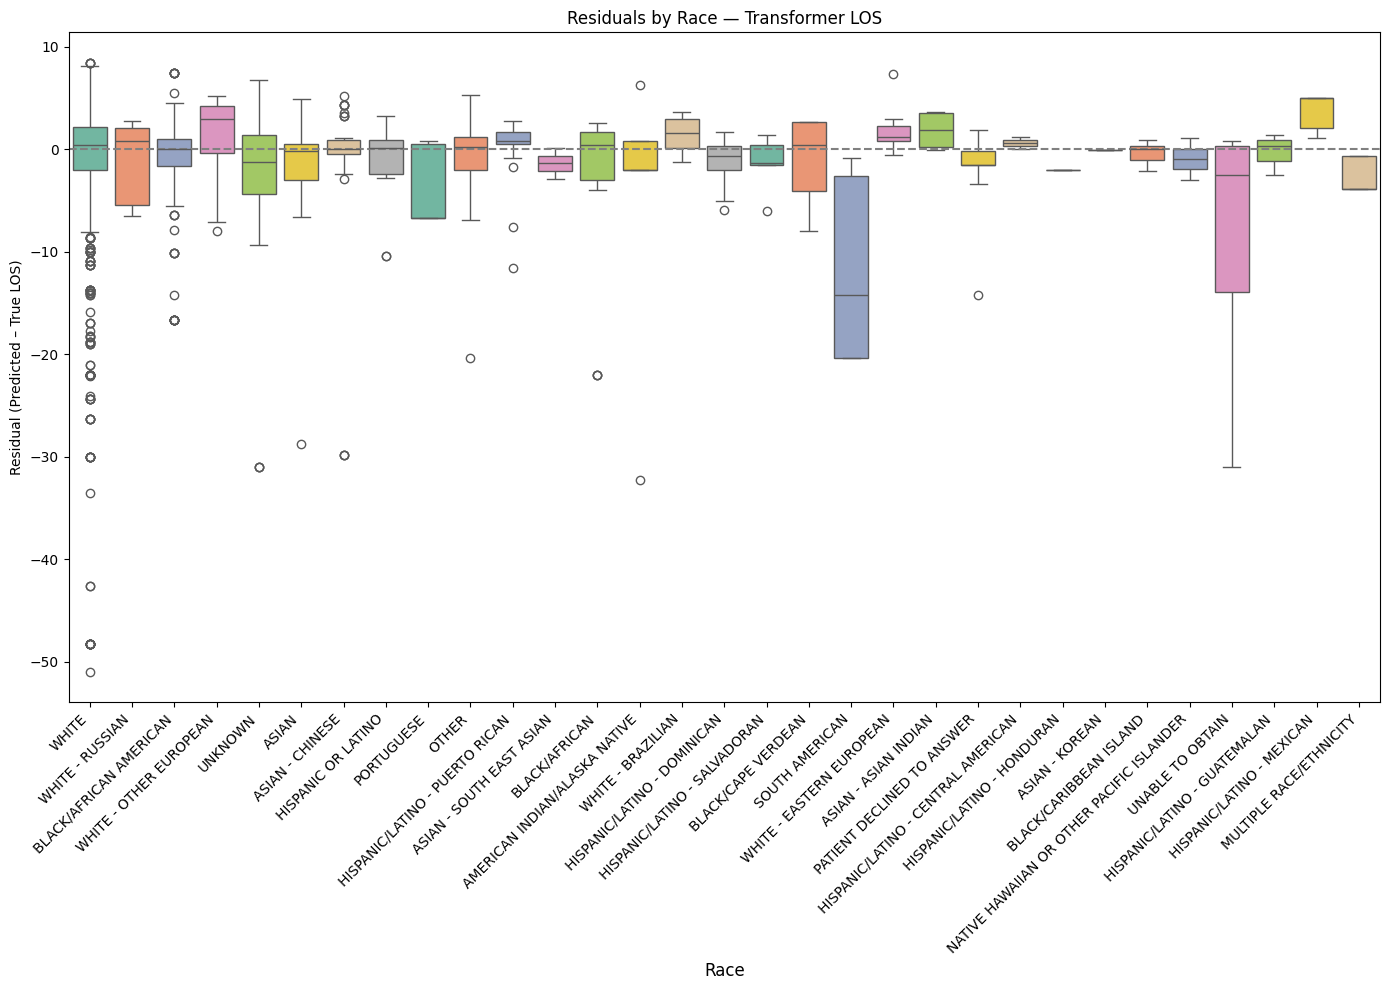

In [ ]:
# Plot MAE per race
mae_table = plot_mae_by_race(transformer_los, model_name="Transformer LOS")
display(mae_table)

# Plot residual distributions
plot_residuals_by_race(transformer_los, model_name="Transformer LOS")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_f1_by_race(perrace_df, model_name=None):
    """
    Plot F1 scores across race groups.
    perrace_df: DataFrame with columns ['Model','Race','F1'].
    model_name: if None, plots all models; else filter to one model.
    """
    df = perrace_df.copy()
    if model_name:
        df = df[df["Model"] == model_name]

    plt.figure(figsize=(8,5))
    sns.barplot(data=df, x="Race", y="F1", hue="Model", palette="viridis")
    plt.title("F1 Score by Race" + (f" — {model_name}" if model_name else ""))
    plt.ylabel("F1 Score")
    plt.xlabel("Race")
    plt.ylim(0,1)  # F1 is always 0–1
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [ ]:
def count_bad_performance(perrace_df_cls, perrace_df_reg):
    """
    perrace_df_cls: classification metrics table with ['Model','Race','F1','AUC']
    perrace_df_reg: regression metrics table with ['Model','Race','R²']
    """
    results = []

    # classification: count races with F1==0
    f1_zero = (perrace_df_cls["F1"] == 0).sum()
    results.append({"Metric":"F1==0", "Count": int(f1_zero)})

    # classification: count races with AUC==0.5 (random guessing)
    auc_half = (perrace_df_cls["AUC"].round(3) == 0.500).sum()
    results.append({"Metric":"AUC==0.5", "Count": int(auc_half)})

    # regression: count races with R²==0
    r2_zero = (perrace_df_reg["R2"].round(3) == 0.000).sum()
    results.append({"Metric":"R2==0", "Count": int(r2_zero)})

    return pd.DataFrame(results)


In [ ]:
byrace_reg

,Model,Race,N,MAE,RMSE,MSE,R2,MAPE %,sMAPE %
62,LSTM_LOS,AMERICAN INDIAN/ALASKA NATIVE,5,9.230303,15.600461,243.374390,-0.129762,325.730174,74.038404
63,LSTM_LOS,ASIAN,34,2.753978,5.202291,27.063828,0.106482,80.944755,57.403279
64,LSTM_LOS,ASIAN - ASIAN INDIAN,4,0.503393,0.575299,0.330969,-7.480288,45.218869,50.954393
65,LSTM_LOS,ASIAN - CHINESE,39,3.116855,7.056836,49.798940,0.358923,120.559092,50.325506
66,LSTM_LOS,ASIAN - KOREAN,1,0.097141,0.097141,0.009436,NaN,5.105241,5.238972
...,...,...,...,...,...,...,...,...,...
57,XGB_LOS,WHITE,8335,2.241584,4.316316,18.630582,0.446316,289.634187,63.181155
58,XGB_LOS,WHITE - BRAZILIAN,12,3.014252,3.406424,11.603728,-0.011584,129.504550,77.864583
59,XGB_LOS,WHITE - EASTERN EUROPEAN,18,2.433120,3.690623,13.620702,-2.941802,583.733994,64.332654
60,XGB_LOS,WHITE - OTHER EUROPEAN,566,3.778172,7.723983,59.659907,0.185406,103.599701,54.516444


In [ ]:
summary_bad = count_bad_performance(byrace_cls, byrace_reg)
print(summary_bad)


     Metric  Count
0     F1==0     95
1  AUC==0.5      1
2     R2==0      0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_los_scatter_by_race(df, model_name="LOS Model", max_points=2000):
    """
    Overlay dotplot of true vs predicted LOS, colored by race.
    df must have ['y_true','y_pred','race'].
    """
    df = df.copy()
    if len(df) > max_points:
        df = df.sample(max_points, random_state=42)  # downsample to keep plot readable

    plt.figure(figsize=(7,6))
    sns.scatterplot(data=df, x="y_true", y="y_pred", hue="race", alpha=0.6, s=20)
    lo, hi = df[["y_true","y_pred"]].min().min(), df[["y_true","y_pred"]].max().max()
    plt.plot([lo,hi],[lo,hi], "--", color="gray")  # perfect line
    plt.xlabel("True LOS (days)")
    plt.ylabel("Predicted LOS (days)")
    plt.title(f"True vs Predicted LOS — {model_name}")
    #plt.legend(title="Race", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.legend([],[],frameon=False)   # 👈 remove legend
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_los_distribution(df, model_name="LOS Model", max_points=2000):
    """
    Overlaid dotplots of LOS distributions (true vs predicted).
    """
    df = df.copy()
    if len(df) > max_points:
        df = df.sample(max_points, random_state=42)

    plt.figure(figsize=(10,8))
    sns.stripplot(data=df.melt(
        id_vars="race",
        value_vars=["y_true","y_pred"],
        var_name="Type", value_name="LOS"),
        x="race", y="LOS", hue="Type",
        dodge=True, jitter=0.3, alpha=0.6
    )
    plt.title(f"LOS Distribution by Ethnic Group — {model_name}")
    plt.ylabel("Length of Stay (days)")
    plt.xlabel("Ethnic Group", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

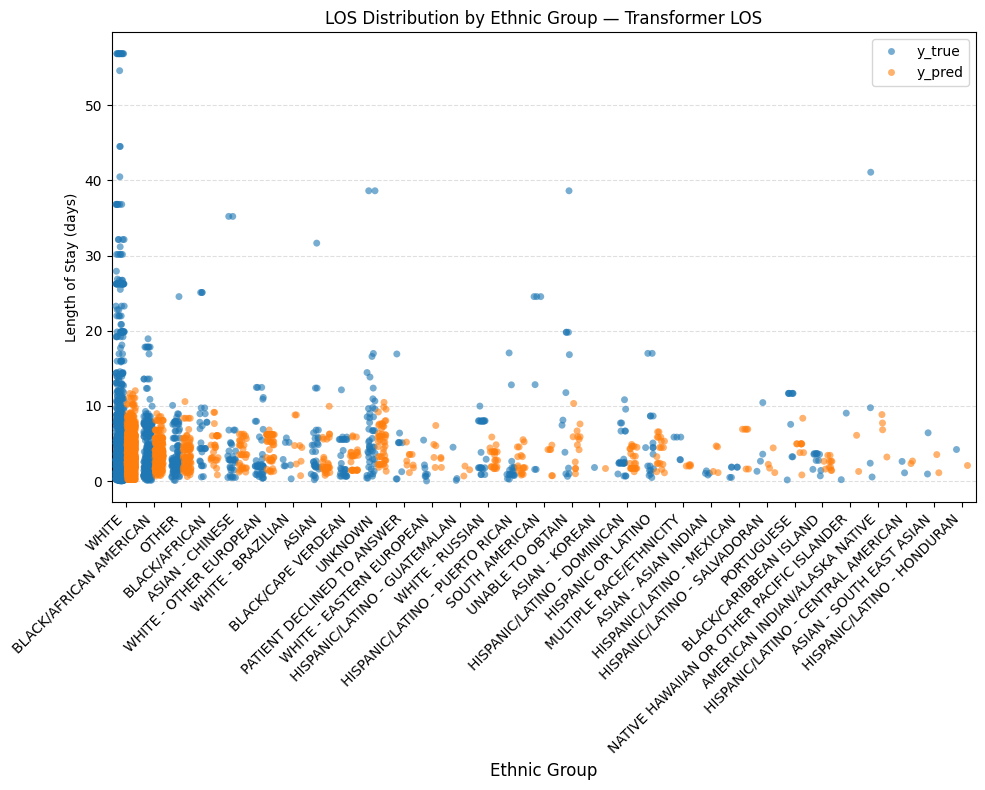

In [ ]:
#plot_los_scatter_by_race(transformer_los, model_name="Transformer LOS")
plot_los_distribution(transformer_los, model_name="Transformer LOS")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_los_overlay_by_model(reg_frames, max_points=2000):
    """
    Overlayed dotplot of LOS predictions per model, compared to true LOS.
    reg_frames: list of DataFrames, each with ['model_name','y_true','y_pred'].
    """
    # combine into one long dataframe
    dfs = []
    for df in reg_frames:
        model = df["model_name"].iloc[0]
        tmp = df[["y_true","y_pred"]].copy()
        tmp["Model"] = model
        dfs.append(tmp)
    all_df = pd.concat(dfs, ignore_index=True)

    # downsample to keep plot readable
    if len(all_df) > max_points:
        all_df = all_df.sample(max_points, random_state=42)

    # melt so we have one column for "True" vs "Pred"
    long_df = all_df.melt(id_vars=["Model"],
                          value_vars=["y_true","y_pred"],
                          var_name="Type", value_name="LOS")

    plt.figure(figsize=(10,5))
    sns.stripplot(data=long_df, x="Model", y="LOS", hue="Type",
                  dodge=True, jitter=0.25, alpha=0.5)
    plt.title("LOS Predictions vs True — Across Models")
    plt.ylabel("Length of Stay (days)")
    plt.xlabel("Model")
    plt.legend(title="")
    plt.tight_layout()
    plt.show()


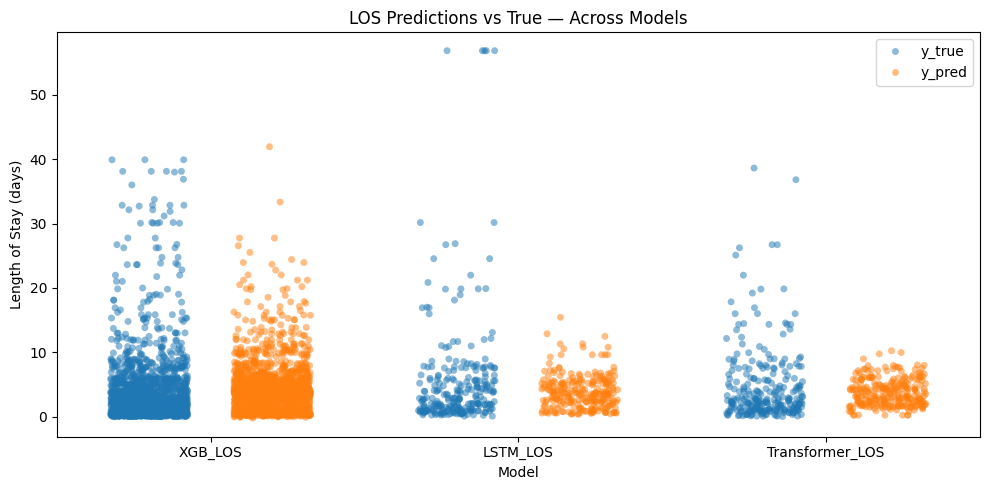

In [ ]:
plot_los_overlay_by_model(reg_frames)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_los_overlay_diagonal(reg_frames, max_points=2000):
    """
    Overlay scatterplots of True vs Predicted LOS for multiple models.
    Each model has a different colour. Diagonal line = perfect prediction.
    reg_frames: list of DataFrames, each with ['model_name','y_true','y_pred'].
    """
    plt.figure(figsize=(7,6))

    for df in reg_frames:
        model = df["model_name"].iloc[0]
        tmp = df[["y_true","y_pred"]].copy()
        if len(tmp) > max_points:
            tmp = tmp.sample(max_points, random_state=42)
        plt.scatter(tmp["y_true"], tmp["y_pred"], s=15, alpha=0.5, label=model)

    # add perfect diagonal
    all_true = pd.concat([df["y_true"] for df in reg_frames])
    lo, hi = all_true.min(), all_true.max()
    plt.plot([lo,hi],[lo,hi], "--", color="black", linewidth=1)

    plt.xlabel("True LOS (days)")
    plt.ylabel("Predicted LOS (days)")
    plt.title("True vs Predicted LOS")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


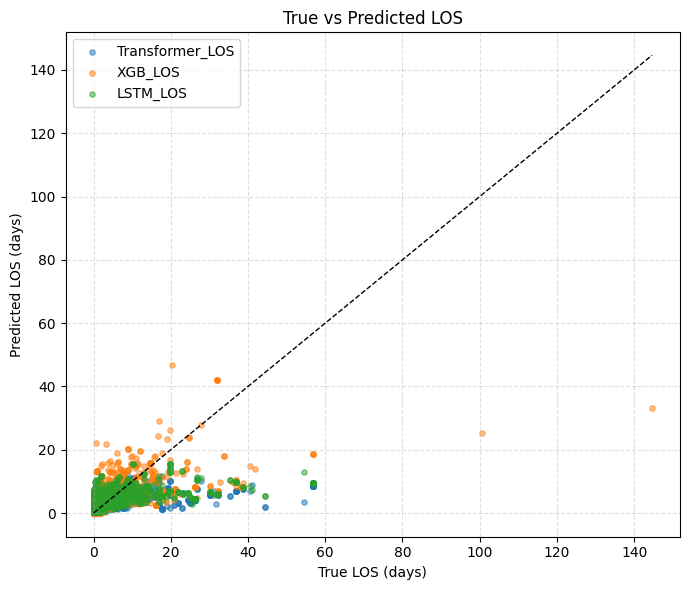

In [ ]:
plot_los_overlay_diagonal(reg_frames)


In [ ]:
reg_frames

[           model_name  subject_id    y_true    y_pred             race
 0     Transformer_LOS    10007117  0.504167  1.082284            WHITE
 1     Transformer_LOS    10007174  2.006250  6.776549            WHITE
 2     Transformer_LOS    10007174  2.006250  6.776549            WHITE
 3     Transformer_LOS    10007174  2.006250  6.776549            WHITE
 4     Transformer_LOS    10011912  8.025695  1.910906  WHITE - RUSSIAN
 ...               ...         ...       ...       ...              ...
 2246  Transformer_LOS    19984218  0.909722  5.020797            WHITE
 2247  Transformer_LOS    19984218  0.909722  5.020797            WHITE
 2248  Transformer_LOS    19984218  0.909722  5.020797            WHITE
 2249  Transformer_LOS    19986053  3.406250  2.837314            WHITE
 2250  Transformer_LOS    19986309  0.614583  2.101186    BLACK/AFRICAN
 
 [2251 rows x 5 columns],
       model_name  subject_id    y_true     y_pred           race
 0        XGB_LOS    10007117  0.504167   

In [ ]:
reg_frames_no_xgb = [df for df in reg_frames if "xgb" not in df["model_name"].iloc[0].lower()]

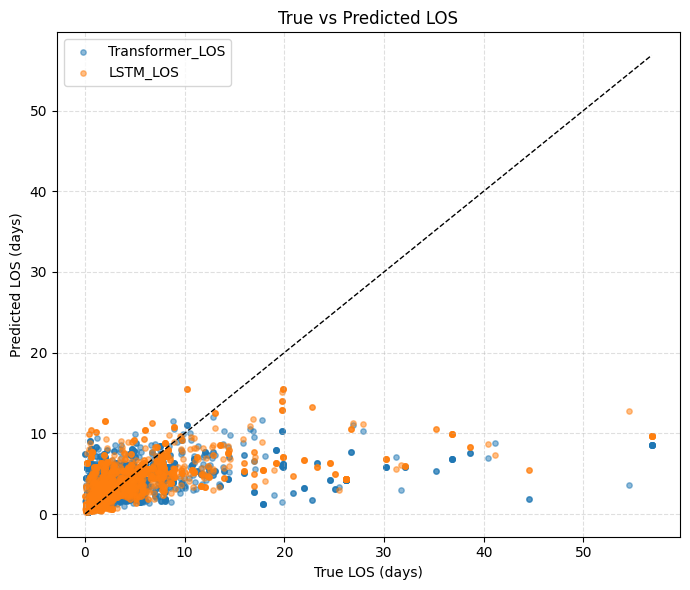

In [ ]:
plot_los_overlay_diagonal(reg_frames_no_xgb)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-9, None))) * 100
    smape = np.mean(2 * np.abs(y_pred - y_true) / np.clip(np.abs(y_pred) + np.abs(y_true), 1e-9, None)) * 100
    return {
        "MAE": round(mae,2),
        "RMSE": round(rmse,2),
        "R²": round(r2,2),
        "MAPE %": round(mape,2),
        "sMAPE %": round(smape,2)
    }

def compare_los_models(reg_frames):
    """
    reg_frames: list of DataFrames, each with ['model_name','y_true','y_pred'].
    Returns a summary DataFrame of metrics per model.
    """
    rows = []
    for df in reg_frames:
        model = df["model_name"].iloc[0]
        y_true = df["y_true"].to_numpy()
        y_pred = df["y_pred"].to_numpy()
        metrics = regression_metrics(y_true, y_pred)
        rows.append({"Model": model, **metrics})
    return pd.DataFrame(rows).sort_values("MAE")


In [ ]:
los_summary = compare_los_models(reg_frames)
print(display(los_summary))


,Model,MAE,RMSE,R²,MAPE %,sMAPE %
1,XGB_LOS,2.46,5.40,0.39,228.89,60.90
2,LSTM_LOS,2.91,6.30,0.24,130.78,55.54
0,Transformer_LOS,3.44,6.79,0.11,211.49,68.55


None
